# MCYSD-23 Machine Learning Optimization Lecture

A Jupyter notebook demonstrating concepts of machine learning optimization.
It covers GD, AdaGrad, RMSProp, Adam, Momentum, and compares some concepts to sklearn.
It discusses learning rate and hyperparameter tuning, and provides visualizations for comparisons and understanding of convergence and behaviours.

Group Members
- John P.
- Alvaro G. G.
- Chris D.

In [1]:
## Imports
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
import inspect
from math import sqrt
from ipywidgets import interact, fixed

### Introduction: Function and Slope from Derivative

We have a function and want to get to the lowest point to minimize it.
This represents our loss function which we want to minimize.

We can use the derivative to find the slope of the function at any point.
Naively, we can take a step down the slope to get closer to the minimum.
This is our gradient, which we use to descend the function.

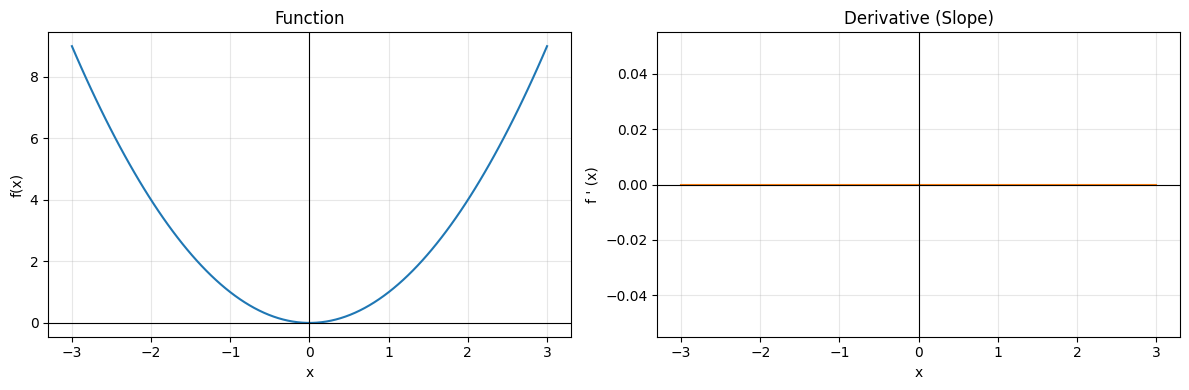

In [2]:
# This is our function
# It represents our loss function
# We want to minimize this
def f(x):
    return x**2

# Our derivative can tell us which direction "down" is
def df(x):
    return x*0 #TODO: Calculate the derivative

# Domain
x = np.linspace(-3, 3, 100)

# Side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(x, f(x), color="tab:blue")
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_title("Function")
axes[0].set_xlabel("x")
axes[0].set_ylabel("f(x)")
axes[0].grid(True, alpha=0.3)

axes[1].plot(x, df(x), color="tab:orange")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Derivative (Slope)")
axes[1].set_xlabel("x")
axes[1].set_ylabel("f ' (x)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Interactive function

In [3]:
def interactive_optimizer_plot(
    optimizer,
    gradient,
    loss_function,
    x_range=(-3, 3),
    zoom_on_points=True,
    zoom_margin=0.5,
    num_points=400,
    default_params=None,
    slider_config=None,
    title=None
):
    # Initialize default parameter dictionaries if not provided
    if default_params is None:
        default_params = {}

    if slider_config is None:
        slider_config = {}

    # Inspect optimizer function to get its parameters
    sig = inspect.signature(optimizer)
    params = sig.parameters

    # Possible parameters we want to control with sliders
    candidate_controls = [
        "learning_rate",
        "num_iterations",
        "x_start",
        "beta",
        "beta1",
        "beta2",
    ]

    # Default slider ranges and steps
    default_slider_settings = {
        "learning_rate": {"min": 0.001, "max": 2.0, "step": 0.001},
        "num_iterations": {"min": 1, "max": 100, "step": 1},
        "x_start": {"min": x_range[0], "max": x_range[1], "step": 0.1},
        "beta": {"min": 0.0, "max": 0.999, "step": 0.01},
        "beta1": {"min": 0.0, "max": 0.999, "step": 0.01},
        "beta2": {"min": 0.0, "max": 0.999, "step": 0.01},
    }

    controls = {}

    # Create sliders only for parameters that exist in the optimizer
    for name in candidate_controls:
        if name not in params:
            continue

        param = params[name]

        # Determine default value for each parameter
        if name in default_params:
            value = default_params[name]
        elif param.default is not inspect._empty:
            value = param.default
        else:
            # Fallback values if nothing is provided
            fallback = {
                "learning_rate": 0.1,
                "num_iterations": 30,
                "x_start": -2.0,
                "beta": 0.5,
                "beta1": 0.5,
                "beta2": 0.5,
            }
            value = fallback[name]

        # Merge default slider settings with user overrides
        cfg = default_slider_settings[name].copy()
        cfg.update(slider_config.get(name, {}))

        # Create integer slider for iterations, float sliders otherwise
        if name == "num_iterations":
            controls[name] = widgets.IntSlider(
                value=int(value),
                min=int(cfg["min"]),
                max=int(cfg["max"]),
                step=int(cfg["step"]),
                description=name,
                continuous_update=False
            )
        else:
            controls[name] = widgets.FloatSlider(
                value=float(value),
                min=float(cfg["min"]),
                max=float(cfg["max"]),
                step=float(cfg["step"]),
                description=name,
                readout_format=".3f",
                continuous_update=False
            )

    # Pass fixed (non-interactive) arguments
    controls["gradient"] = fixed(gradient)
    controls["loss_function"] = fixed(loss_function)

    # Function that performs optimization and plots results
    def _plot(**kwargs):
        # Run optimizer and get trajectory
        positions, losses = optimizer(**kwargs)

        positions = np.asarray(positions)
        losses = np.asarray(losses)

        # Create smooth curve for loss function
        xs = np.linspace(x_range[0], x_range[1], num_points)
        ys = np.array([loss_function(x) for x in xs])

        # Create two subplots: trajectory and loss evolution
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # Plot loss function and optimizer steps
        axes[0].plot(xs, ys)
        axes[0].scatter(positions, [loss_function(x) for x in positions], s=40)
        axes[0].plot(positions, [loss_function(x) for x in positions], linestyle="--", alpha=0.8)

        axes[0].set_title(title or f"Trajectory of {optimizer.__name__}")
        axes[0].set_xlabel("x")
        axes[0].set_ylabel("Loss")

        # Plot how loss changes over iterations
        axes[1].plot(range(len(losses)), losses, marker="o")
        axes[1].set_title("Loss evolution")
        axes[1].set_xlabel("Iteration")
        axes[1].set_ylabel("Loss")

        # Optionally zoom into region where optimizer moves
        if zoom_on_points:
            xmin, xmax = positions.min(), positions.max()
            axes[0].set_xlim(xmin - zoom_margin, xmax + zoom_margin)

            y_vals = [loss_function(x) for x in positions]
            ymin, ymax = min(y_vals), max(y_vals)
            axes[0].set_ylim(ymin - zoom_margin, ymax + zoom_margin)

        plt.tight_layout()
        plt.show()

    # Return interactive widget
    return interact(_plot, **controls)

### Default functions

$$\begin{align*}
L(x) &= x^2 + 0.5 * sin(5x)\\
\nabla_L(x) &= 2x + 2.5*cos(5x)
\end{align*}$$

In [4]:
def loss_function(x):
    return x**2 + 0.5*np.sin(5*x)

def gradient(x):
    return 2*x + 2.5*np.cos(5*x)

### Gradient Descent

In gradient descent, you try to minimize a function $L$ by using the gradient $\nabla L$ to follow the *slope* of the function. As such, you repeat the following iteration:
$$\begin{align*}
    g_t &= \nabla L(w_t)\\[5pt]
    w_{t+1} &= w_t - \eta\cdot g_t
\end{align*}$$
where $\eta$ is the learning rate.

In [5]:
def gradient_descent(learning_rate, num_iterations=30, x_start=-2.0, gradient=gradient, loss_function=loss_function):
    x = np.array(x_start)
    losses = [loss_function(x)]
    positions = [x]

    for _ in range(num_iterations):
        grad = np.array(gradient(x))
        x = x - learning_rate * grad
        losses.append(loss_function(x))
        positions.append(x)

    return positions, losses

In [6]:
interactive_optimizer_plot(
    optimizer=gradient_descent,
    gradient=gradient,
    loss_function=loss_function,
    x_range=(-3, 3),
    zoom_on_points=False,
    default_params={
        "learning_rate": 0.1,
        "num_iterations": 20,
        "x_start": 2.0
    },
    title="Gradient Descent"
)

interactive(children=(FloatSlider(value=0.1, continuous_update=False, description='learning_rate', max=2.0, mi…

<function __main__.interactive_optimizer_plot.<locals>._plot(**kwargs)>

#### Cases where GradDescent performs poorly

##### 1. Gradient Descent doesn't necessarily converge if the gradient is unbounded.

$$\begin{align*}
    L(x,y) &= 0.1  x^4\\[5pt]
    \nabla_L(x,y) &= 0.4  x^3
\end{align*}$$

In [7]:
def unbounded_function(x):
    return 0.1*x**4

def unbounded_gradient(x):
    return 0.4*x**3

In [ ]:
# If the learning rate is higher than 1/(maximum of gradient), 
# we don't necessarily converge, even in a convex function.
interactive_optimizer_plot(
    optimizer=gradient_descent,
    gradient=unbounded_gradient,
    loss_function=unbounded_function,
    x_range=(-6, 6),
    zoom_on_points=False,
    default_params={
        "learning_rate": 0.5,
        "num_iterations": 2,
        "x_start": 2
    },
    title="Gradient Descent"
)

interactive(children=(FloatSlider(value=0.5, continuous_update=False, description='learning_rate', max=2.0, mi…

<function __main__.interactive_optimizer_plot.<locals>._plot(**kwargs)>

##### 2. Small noise can cause problems 

$$\begin{align*}
    L(x,y) &= 0.5  x^2 + 0.1\cdot \sin(100x)\\[5pt]
    \nabla_L(x,y) &= x + 10\cdot \cos(100x)
\end{align*}$$

In [9]:
def noise_function(x):
    return 0.5 * x**2 + 0.1 * np.sin(100*x)

def noise_gradient(x):
    return x + 10 * np.cos(100*x)

In [ ]:
# If the learning rate is higher than 1/(maximum of gradient), 
# we don't necessarily converge, even in a convex function.
interactive_optimizer_plot(
    optimizer=gradient_descent,
    gradient=noise_gradient,
    loss_function=noise_function,
    x_range=(-5, 5),
    zoom_on_points=False,
    default_params={
        "learning_rate": 0.5,
        "num_iterations": 1,
        "x_start": 2
    },
    title="Gradient Descent"
)

interactive(children=(FloatSlider(value=0.5, continuous_update=False, description='learning_rate', max=2.0, mi…

<function __main__.interactive_optimizer_plot.<locals>._plot(**kwargs)>

##### 3. In multidimensional spaces, the learning rate is the same for every dimension.


$$\begin{align*}
    L(x,y) &= x^2 + 1000\cdot y^2\\[5pt]
    \nabla_L(x,y) &= 
    \begin{pmatrix}
        2x\\
        2000y
    \end{pmatrix}
\end{align*}$$

In [11]:
def multi_function(x):
    return x[0]**2 + 1000*x[1]**2

def multi_gradient(x):
    return np.array([2*x[0], 2000*x[1]])

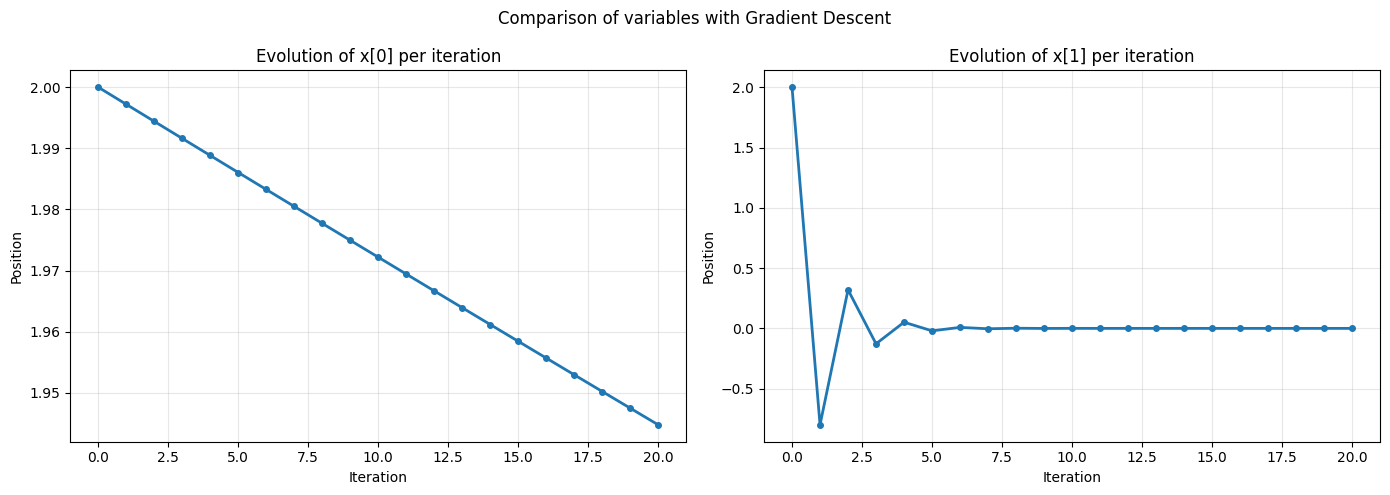

In [12]:
# We see here that learning rate is adapted to x[1], so x[0] goes towards the 
# minimum very slowly, while x[1] gets there really fast
positions1, losses1 = gradient_descent(0.0007, 
                                     num_iterations=20, 
                                     x_start=[2.0, 2.0], 
                                     gradient=multi_gradient, 
                                     loss_function=multi_function)
positions1 = np.array(positions1)

pos_x = positions1[:,0]
pos_y = positions1[:,1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fig.suptitle("Comparison of variables with Gradient Descent")

axes[0].plot(pos_x, 'o-', linewidth=2, markersize=4)
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Position')
axes[0].set_title('Evolution of x[0] per iteration')
axes[0].grid(True, alpha=0.3)

axes[1].plot(pos_y, 'o-', linewidth=2, markersize=4)
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Position')
axes[1].set_title('Evolution of x[1] per iteration')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### AdaGrad

AdaGrad improves on regular gradient descent by having an adaptive learning rate, which leads to large steps for a low gradient (exploration), and small steps for a large gradient (exploitation). For this, you introduce $v_t$, which is the cumulative sum of all previous gradients squared.
$$\begin{align*}
    v_0 &= 0\\
    v_t &= v_{t-1} + g_t^2\\[2pt]
    w_{t+1} &= w_t - \frac{\eta}{\sqrt{v_t}+\epsilon} \cdot g_t
\end{align*}$$
where $\epsilon$ is a small value to avoid division by 0.

In [13]:
## Question: What is the point of eps
def ada_grad(learning_rate, num_iterations=30, x_start=-2.0, gradient=gradient, loss_function=loss_function):
    eps = 1e-16
    x = np.array(x_start)
    losses = [loss_function(x)]
    positions = [x]
    vt = 0
    for _ in range(num_iterations):
        grad = np.array(gradient(x))
        vt += grad**2
        x = x - learning_rate * grad / (np.sqrt(vt) + eps)
        losses.append(loss_function(x))
        positions.append(x)

    return positions, losses

In [14]:
interactive_optimizer_plot(
    optimizer=ada_grad,
    gradient=gradient,
    loss_function=loss_function,
    x_range=(-3, 4),
    zoom_on_points=False,
    default_params={
        "learning_rate": 0.2,
        "num_iterations": 40,
        "x_start": 4.0
    },
    title="AdaGrad"
)

interactive(children=(FloatSlider(value=0.2, continuous_update=False, description='learning_rate', max=2.0, mi…

<function __main__.interactive_optimizer_plot.<locals>._plot(**kwargs)>

As $v_t$ is calculated per variable, we get better adaption of the learning rate in multidimensional spaces.

In [15]:
def multi_function(x):
    return x[0]**2 + 1000*x[1]**2

def multi_gradient(x):
    return np.array([2*x[0], 2000*x[1]])

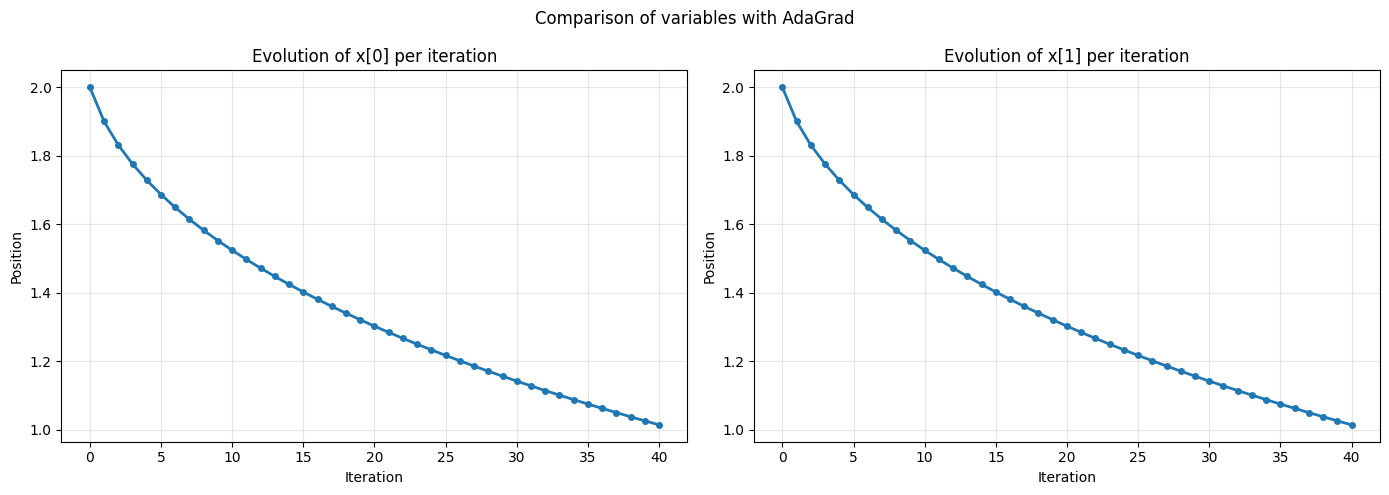

In [16]:
# We see here that the learning rate can be set a lot higher, and actually works the same 
# for x[0] md x[1]
# But we also see the slowing-down effect of AdaGrad
positions1, losses1 = ada_grad(0.1, 
                                     num_iterations=40, 
                                     x_start=[2.0, 2.0], 
                                     gradient=multi_gradient, 
                                     loss_function=multi_function)
positions1 = np.array(positions1)

pos_x = positions1[:,0]
pos_y = positions1[:,1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Comparison of variables with AdaGrad")

axes[0].plot(pos_x, 'o-', linewidth=2, markersize=4)
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Position')
axes[0].set_title('Evolution of x[0] per iteration')
axes[0].grid(True, alpha=0.3)

axes[1].plot(pos_y, 'o-', linewidth=2, markersize=4)
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Position')
axes[1].set_title('Evolution of x[1] per iteration')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### RMSProp

In AdaGrad, $v_t$ is constantly growing. This can lead to a very small learning value, so the progress each round becomes minimal for high learning rates. RMSProp avoids this by using a moving average. For this, we introduce an additional parameter $\beta$, which defines the importance of the accumulated averages versus the current gradient.
$$\begin{align*}
    v_0 &= 0\\[2pt]
    v_t &= \beta v_{t-1} + (1-\beta) g_t^2\\[5pt]
    \hat{v}_t &= \frac{v_t}{1-\beta^t}\\
    w_{t+1} &= w_t - \frac{\eta}{\sqrt{\hat{v}_t}+\epsilon} \cdot g_t
\end{align*}$$
$\hat{v}_t$ is used to offset the bias created by the initial choice $v_0 = 0$.

In [17]:
## Question: what does beta do?
## Question: What happens if beta is 0?
def RMSProp(learning_rate, num_iterations=30, x_start=-2.0, beta=0.5, gradient=gradient, loss_function=loss_function):
    eps = 1e-16
    x = np.array(x_start)
    losses = [loss_function(x)]
    positions = [x]
    vt = 0
    for t in range(1, num_iterations + 1):
        grad = np.array(gradient(x))
        vt = beta * vt + (1-beta) * grad**2
        vt_bias = vt / (1-beta**t)
        x = x - learning_rate * grad / (np.sqrt(vt_bias) + eps)
        losses.append(loss_function(x))
        positions.append(x)

    return positions, losses

In [ ]:
interactive_optimizer_plot(
    optimizer=RMSProp,
    gradient=gradient,
    loss_function=loss_function,
    x_range=(-3, 4),
    zoom_on_points=False,
    default_params={
        "learning_rate": 0.2,
        "num_iterations": 40,
        "x_start": 4.0,
        "beta": 0.9
    },
    title="RMSProp"
)

interactive(children=(FloatSlider(value=0.2, continuous_update=False, description='learning_rate', max=2.0, mi…

<function __main__.interactive_optimizer_plot.<locals>._plot(**kwargs)>

The smoothing helps with noise in functions.

In [19]:
def noise_function(x):
    return 0.5 * x**2 + 0.1 * np.sin(100*x)

def noise_gradient(x):
    return x + 10 * np.cos(100*x)

In [20]:
interactive_optimizer_plot(
    optimizer=RMSProp,
    gradient=noise_gradient,
    loss_function=noise_function,
    x_range=(-3, 4),
    zoom_on_points=False,
    default_params={
        "learning_rate": 0.5,
        "num_iterations": 40,
        "x_start": 4.0,
        "beta": 0.7
    },
    title="RMSProp"
)

interactive(children=(FloatSlider(value=0.5, continuous_update=False, description='learning_rate', max=2.0, mi…

<function __main__.interactive_optimizer_plot.<locals>._plot(**kwargs)>

For multi-variable functions, we also get a cleaner descent:

In [21]:
def multi_function(x):
    return x[0]**2 + 1000*x[1]**2

def multi_gradient(x):
    return np.array([2*x[0], 2000*x[1]])

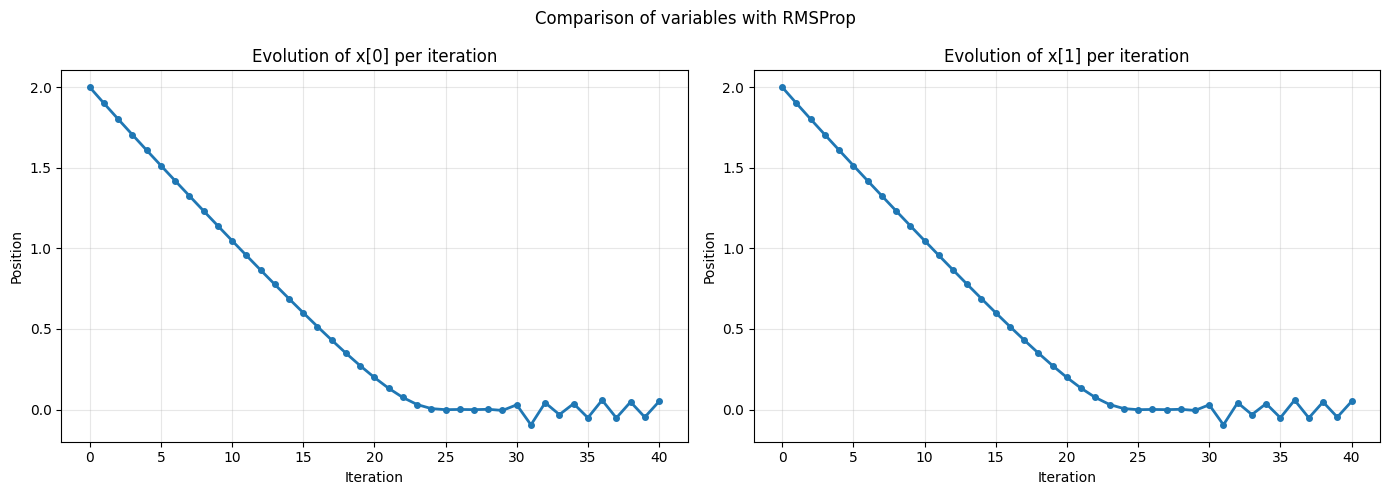

In [22]:
# We see here that the learning rate can be set a lot higher, and actually works the same 
# for x[0] md x[1]
positions1, losses1 = RMSProp(0.1, 
                                     num_iterations=40, 
                                     x_start=[2.0, 2.0], 
                                     gradient=multi_gradient, 
                                     loss_function=multi_function)
positions1 = np.array(positions1)

pos_x = positions1[:,0]
pos_y = positions1[:,1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Comparison of variables with RMSProp")

axes[0].plot(pos_x, 'o-', linewidth=2, markersize=4)
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Position')
axes[0].set_title('Evolution of x[0] per iteration')
axes[0].grid(True, alpha=0.3)

axes[1].plot(pos_y, 'o-', linewidth=2, markersize=4)
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Position')
axes[1].set_title('Evolution of x[1] per iteration')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Momentum

Momentum takes a different approach from the previous versions by adding *momentum*. If we keep moving downhill in one direct, we "speed up" and take bigger steps. If we then hit a spot that descends in the opposite direction, we decelarate. In this case, the step size decreases, but the direction only changes if the slope of the point we hit is large enough.
$$\begin{align*}
    m_0 &= 0\\[2pt]
    m_t &= \beta m_{t-1} + (1-\beta) g_t\\[5pt]
    \hat{m}_t &= \frac{m_t}{1-\beta^t}\\
    w_{t+1} &= w_t - \eta\cdot\hat{m}_t
\end{align*}$$
$\hat{m}_t$ is used to offset the bias created by the initial choice $m_0 = 0$.\
Note that the gradient is now no longer squared, so $m_t$ can be negative.

In [23]:
def momentum(learning_rate, num_iterations=30, x_start=-2.0, beta=0.5,  gradient=gradient, loss_function=loss_function):
    x = np.array(x_start)
    losses = [loss_function(x)]
    positions = [x]
    mt = 0
    for t in range(1, num_iterations + 1):
        grad = np.array(gradient(x))
        mt = beta * mt + (1-beta) * grad
        mt_bias = mt / (1-beta**t)
        x = x - learning_rate * mt_bias
        losses.append(loss_function(x))
        positions.append(x)

    return positions, losses

In [24]:
def f_squared(x):
    return x**2

def grad_squared(x):
    return 2*x

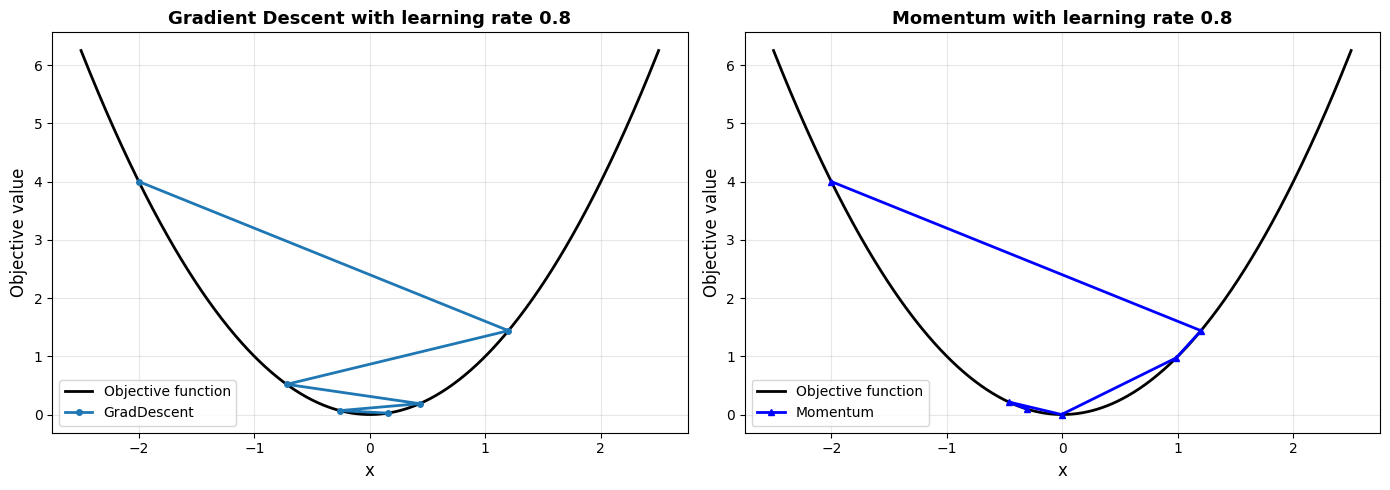

In [25]:
# Learning rates
learning_rate = 0.8

positions_gd, losses_gd = gradient_descent(learning_rate, loss_function=f_squared, gradient=grad_squared, x_start=-2, num_iterations=5)
positions_momentum, losses_momentum = momentum(learning_rate, loss_function=f_squared, gradient=grad_squared, x_start=-2, num_iterations=5)


# Plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Gradient Descent
x_range = np.linspace(-2.5, 2.5, 600)
y_range = f_squared(x_range)
axes[0].plot(x_range, y_range, 'k-', linewidth=2, label='Objective function')
axes[0].plot(positions_gd, losses_gd, 'o-', label=f'GradDescent', linewidth=2, markersize=4)


axes[0].set_xlabel('x', fontsize=12)
axes[0].set_ylabel('Objective value', fontsize=12)
axes[0].set_title('Gradient Descent with learning rate 0.8', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Momentum
x_range = np.linspace(-2.5, 2.5, 600)
y_range = f_squared(x_range)
axes[1].plot(x_range, y_range, 'k-', linewidth=2, label='Objective function')
axes[1].plot(positions_momentum, losses_momentum, '^-', label=f'Momentum', linewidth=2, markersize=4, color='blue')


axes[1].set_xlabel('x', fontsize=12)
axes[1].set_ylabel('Objective value', fontsize=12)
axes[1].set_title('Momentum with learning rate 0.8', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [26]:
interactive_optimizer_plot(
    optimizer=momentum,
    gradient=gradient,
    loss_function=loss_function,
    x_range=(-3, 4),
    zoom_on_points=False,
    default_params={
        "learning_rate": 0.22,
        "num_iterations": 10,
        "x_start": 4.0,
        "beta": 0.9
    },
    title="Momentum"
)

interactive(children=(FloatSlider(value=0.22, continuous_update=False, description='learning_rate', max=2.0, m…

<function __main__.interactive_optimizer_plot.<locals>._plot(**kwargs)>

Momentum helps solve the issue of small noise.

In [27]:
interactive_optimizer_plot(
    optimizer=momentum,
    gradient=noise_gradient,
    loss_function=noise_function,
    x_range=(-5, 5),
    zoom_on_points=False,
    default_params={
        "learning_rate": 0.2,
        "num_iterations": 15,
        "x_start": 3,
        "beta": 0.7
    },
    title="Momentum"
)

interactive(children=(FloatSlider(value=0.2, continuous_update=False, description='learning_rate', max=2.0, mi…

<function __main__.interactive_optimizer_plot.<locals>._plot(**kwargs)>

### Adam

Adam combines RMSProp and Momentum to get smooth gradient direction (from Momentum) and adaptive scaling (from RMSProp).
$$\begin{align*}
    m_0 &= 0\qquad\qquad v_0 = 0\\[2pt]
    m_t &= \beta_1 \cdot m_{t-1} + (1-\beta_1) \cdot g_t\;, \qquad \hat{m}_t = \frac{m_t}{1-\beta_1^t}\\[10pt]
    v_t &= \beta_2 v_{t-1} + (1-\beta_2) g_t^2\;, \qquad \qquad \hat{v}_t = \frac{v_t}{1-\beta_2^t}\\
    w_{t+1} &= w_t - \eta \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}
\end{align*}$$

In [28]:
def adam(learning_rate, num_iterations=30, x_start=-2.0, beta1=0.5, beta2=0.5, gradient=gradient, loss_function=loss_function):
    eps = 1e-16
    x = np.array(x_start)
    losses = [loss_function(x)]
    positions = [x]
    mt = 0
    vt = 0
    for t in range(1, num_iterations + 1):
        grad = np.array(gradient(x))

        mt = beta1 * mt + (1-beta1) * grad
        mt_bias = mt / (1-beta1**t)

        vt = beta2 * vt + (1-beta2) * grad**2
        vt_bias = vt / (1-beta2**t)

        x = x  - learning_rate * mt_bias / (np.sqrt(vt_bias) + eps)
        losses.append(loss_function(x))
        positions.append(x)

    return positions, losses

In [29]:
interactive_optimizer_plot(
    optimizer=adam,
    gradient=gradient,
    loss_function=loss_function,
    x_range=(-3, 3),
    zoom_on_points=False,
    default_params={
        "learning_rate": 0.3,
        "num_iterations": 15,
        "x_start": 2.0,
        "beta1": 0.7,
        "beta2": 0.7
    },
    title="Adam"
)

interactive(children=(FloatSlider(value=0.3, continuous_update=False, description='learning_rate', max=2.0, mi…

<function __main__.interactive_optimizer_plot.<locals>._plot(**kwargs)>

### Comparison

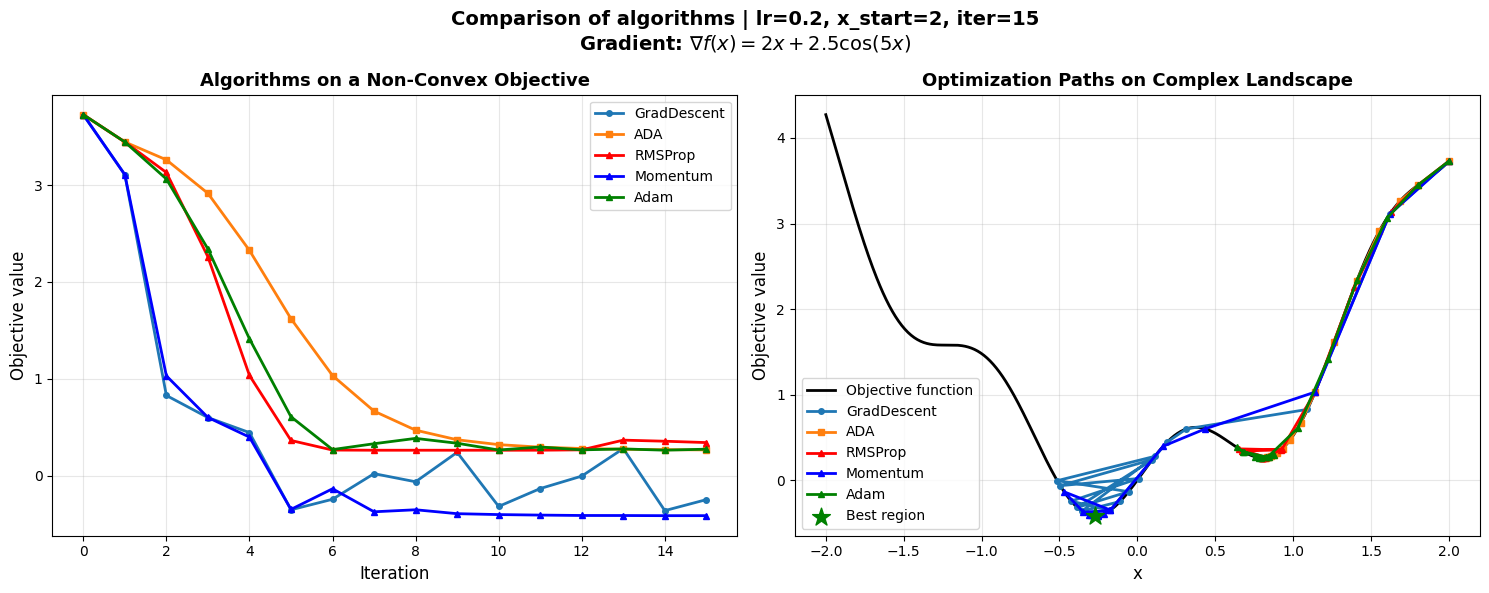

In [30]:
# Learning rates
learning_rate_comparison = 0.2

# Start
x_start_comparison = 2

# Number of iteration
num_iteration_comparison = 15

positions_gd, losses_gd = gradient_descent(learning_rate=learning_rate_comparison, x_start=x_start_comparison, num_iterations=num_iteration_comparison, loss_function=loss_function, gradient=gradient)
positions_ada, losses_ada = ada_grad(learning_rate=learning_rate_comparison, x_start=x_start_comparison, num_iterations=num_iteration_comparison, loss_function=loss_function, gradient=gradient)
positions_rmsp, losses_rsmp = RMSProp(learning_rate=learning_rate_comparison, x_start=x_start_comparison, num_iterations=num_iteration_comparison, loss_function=loss_function, gradient=gradient)
positions_momentum, losses_momentum = momentum(learning_rate=learning_rate_comparison, x_start=x_start_comparison, num_iterations=num_iteration_comparison, loss_function=loss_function, gradient=gradient)
positions_adam, losses_adam = adam(learning_rate=learning_rate_comparison, x_start=x_start_comparison, num_iterations=num_iteration_comparison, loss_function=loss_function, gradient=gradient)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

fig.suptitle(
    rf'Comparison of algorithms | lr={learning_rate_comparison}, x_start={x_start_comparison}, iter={num_iteration_comparison}'
    '\n'
    r'Gradient: $\nabla f(x) = 2x + 2.5 \cos(5x)$',
    fontsize=14,
    fontweight='bold'
)

# Plot 1: Objective value over iterations
iterations = range(len(losses_gd))
axes[0].plot(iterations, losses_gd, 'o-', label=f'GradDescent', linewidth=2, markersize=4)
axes[0].plot(iterations, losses_ada, 's-', label=f'ADA', linewidth=2, markersize=4)
axes[0].plot(iterations, losses_rsmp, '^-', label=f'RMSProp', linewidth=2, markersize=4, color='red')
axes[0].plot(iterations, losses_momentum, '^-', label=f'Momentum', linewidth=2, markersize=4, color='blue')
axes[0].plot(iterations, losses_adam, '^-', label=f'Adam', linewidth=2, markersize=4, color='green')


axes[0].set_xlabel('Iteration', fontsize=12)
axes[0].set_ylabel('Objective value', fontsize=12)
axes[0].set_title('Algorithms on a Non-Convex Objective', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)


# Plot 2: Optimization paths on the landscape
x_range = np.linspace(-2, 2, 600)
y_range = loss_function(x_range)
axes[1].plot(x_range, y_range, 'k-', linewidth=2, label='Objective function')
axes[1].plot(positions_gd, losses_gd, 'o-', label=f'GradDescent', linewidth=2, markersize=4)
axes[1].plot(positions_ada, losses_ada, 's-', label=f'ADA', linewidth=2, markersize=4)
axes[1].plot(positions_rmsp, losses_rsmp, '^-', label=f'RMSProp', linewidth=2, markersize=4, color='red')
axes[1].plot(positions_momentum, losses_momentum, '^-', label=f'Momentum', linewidth=2, markersize=4, color='blue')
axes[1].plot(positions_adam, losses_adam, '^-', label=f'Adam', linewidth=2, markersize=4, color='green')

best_idx = np.argmin(y_range) # Mark an optimal value
axes[1].scatter([x_range[best_idx]], [
    y_range[best_idx]], color='green', s=180, marker='*', label='Best region', zorder=5)

axes[1].set_xlabel('x', fontsize=12)
axes[1].set_ylabel('Objective value', fontsize=12)
axes[1].set_title('Optimization Paths on Complex Landscape', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Neural Networks and Backpropagation (3 Layers)

Backpropagation is the chain rule applied step by step.
In our model we have:

$$
\begin{aligned}
z_1 &= W_1X + b_1, & a_1 &= \sigma(z_1) \\
z_2 &= W_2a_1 + b_2, & a_2 &= \sigma(z_2) \\
z_3 &= W_3a_2 + b_3, & \hat{y} &= \sigma(z_3)
\end{aligned}
$$

Using binary cross-entropy (BCE):

$$
L = -\frac{1}{N}\sum_{i=1}^{N}\left[y_i\log(\hat{y}_i) + (1-y_i)\log(1-\hat{y}_i)\right]
$$

Backprop works from output to input with the chain rule (elementwise product $\odot$):

$$
\begin{aligned}
\delta_3 &= \frac{\partial L}{\partial z_3} = \frac{\hat{y}-y}{N} \\
\delta_2 &= \frac{\partial L}{\partial z_2} = (\delta_3W_3^T)\odot\sigma'(z_2) \\
\delta_1 &= \frac{\partial L}{\partial z_1} = (\delta_2W_2^T)\odot\sigma'(z_1)
\end{aligned}
$$

Then gradients for each layer are:

$$
\frac{\partial L}{\partial W_3} = a_2^T\delta_3,\quad
\frac{\partial L}{\partial W_2} = a_1^T\delta_2,\quad
\frac{\partial L}{\partial W_1} = X^T\delta_1
$$

And once we have the gradients, we can update the weights using gradient descent:

$$
W_i = W_i - \eta \cdot \frac{\partial L}{\partial W_i}
$$


Final loss: 0.003652857384778983
Predictions:
x=[0 0] | target=0 | pred=0.0083
x=[0 1] | target=1 | pred=0.9974
x=[1 0] | target=1 | pred=0.9974
x=[1 1] | target=1 | pred=0.9990


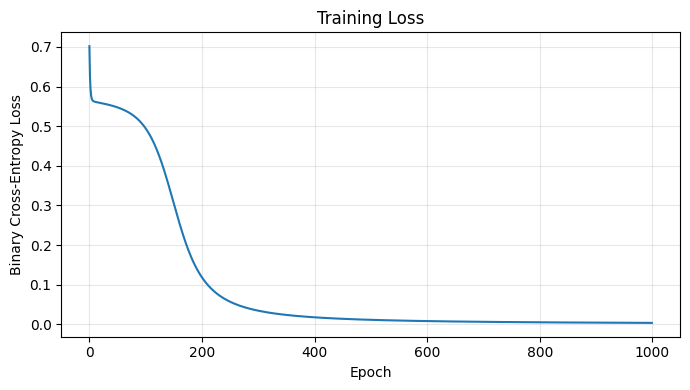

In [31]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(3)

# We use the sigmoid function as our activation function
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))

# We need to know the derivative of the sigmoid for backpropagation
def d_sigmoid(x):
    s = sigmoid(x)
    return s * (1 - s)

# Toy dataset (basically OR logic gate)
X = np.array([[0, 0],
              [0, 1],
              [1, 0],
              [1, 1]], dtype=float)
y = np.array([[0], [1], [1], [1]], dtype=float)

# Layered neural network: 2 -> 4 -> 3 -> 1
# We need to initialize weights and biases for each layer
# - there is research in the best way to initialize there
# - such as Xavier (np.random.randn(fan_out, fan_in) * np.sqrt(2 / fan_in + fan_out))
# - or such as He (np.random.randn(fan_out, fan_in) * np.sqrt(2 / fan_in))
# Input is 2 features
W1 = np.random.randn(2, 4) * 0.5 # Layer 1 has 4 neurons, so 2 -> 4
b1 = np.zeros((1, 4))

W2 = np.random.randn(4, 3) * 0.5 # Layer 2 has 3 neurons, so 4 -> 3
b2 = np.zeros((1, 3))

W3 = np.random.randn(3, 1) * 0.5 # Layer 3 has 1 neuron, so 3 -> 1
b3 = np.zeros((1, 1))
# Output is 1 feature (binary classification)

learning_rate = 0.75
epochs = 1000
loss_history = []

# Training loop
for epoch in range(epochs):
    # Forward pass is simple enough
    z1 = X @ W1 + b1
    a1 = sigmoid(z1)

    z2 = a1 @ W2 + b2
    a2 = sigmoid(z2)

    z3 = a2 @ W3 + b3
    y_hat = sigmoid(z3)

    # Binary cross-entropy loss
    y_hat_clipped = np.clip(y_hat, 1e-12, 1 - 1e-12)
    loss = -np.mean(y * np.log(y_hat_clipped) + (1 - y) * np.log(1 - y_hat_clipped))
    loss_history.append(loss)

    # Backward pass (chain rule step by step)
    # We calculate the gradients for each layer separately
    # For sigmoid + BCE, dL/dz3 simplifies to (y_hat - y)/N
    delta3 = (y_hat - y) / X.shape[0]
    dW3 = a2.T @ delta3
    db3 = np.sum(delta3, axis=0, keepdims=True)

    delta2 = (delta3 @ W3.T) * d_sigmoid(z2)
    dW2 = a1.T @ delta2
    db2 = np.sum(delta2, axis=0, keepdims=True)

    delta1 = (delta2 @ W2.T) * d_sigmoid(z1)
    dW1 = X.T @ delta1
    db1 = np.sum(delta1, axis=0, keepdims=True)

    # Gradient descent update
    W3 -= learning_rate * dW3
    b3 -= learning_rate * db3
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

# Final predictions
z1 = X @ W1 + b1
a1 = sigmoid(z1)
z2 = a1 @ W2 + b2
a2 = sigmoid(z2)
z3 = a2 @ W3 + b3
y_hat = sigmoid(z3)

print("\nFinal loss:", float(loss_history[-1]))
print("Predictions:")
for xi, yi, pi in zip(X, y, y_hat):
    print(f"x={xi.astype(int)} | target={int(yi[0])} | pred={pi[0]:.4f}")

# Loss curve to show learning works
plt.figure(figsize=(7, 4))
plt.plot(loss_history)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Comparison with sklearn


===== COMPARISON =====

--- From Scratch Network ---
Final Loss: 0.003653
Accuracy  : 1.0000

--- sklearn (SGD) ---
Final Loss: 0.003011
Accuracy  : 1.0000

--- sklearn (Adam) ---
Loss final: 0.002024
Accuracy  : 1.0000


/Users/chrisdegrand/Desktop/Uni.lu/Sommersemester_2026/Machine Learning/LiveCoding/ML-optimization-lecture/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


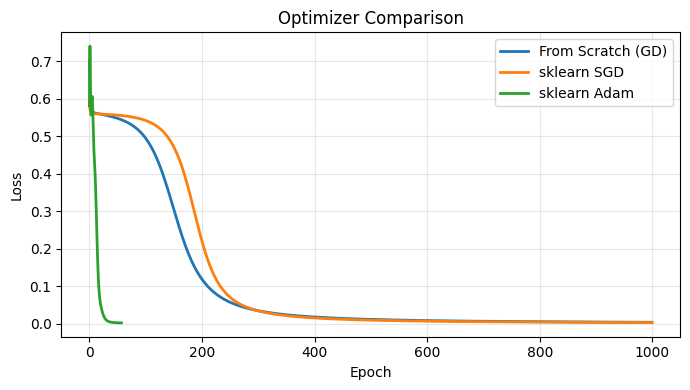

In [32]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import log_loss, accuracy_score

# =========================
# From Scratch Model Results
# =========================

# Flatten predictions
y_hat_scratch = y_hat.ravel()

# Convert probabilities to class labels (threshold = 0.5)
y_pred_scratch = (y_hat_scratch >= 0.5).astype(int)

# Get final loss from training history
scratch_loss = loss_history[-1]

# Compute accuracy
scratch_acc = accuracy_score(y.ravel(), y_pred_scratch)


# =========================
# SGD (sklearn)
# =========================

# Define MLP model using SGD optimizer
mlp = MLPClassifier(
    hidden_layer_sizes=(4, 3),   # 2 hidden layers: 4 neurons, then 3
    activation="logistic",       # Sigmoid activation
    solver="sgd",                # Stochastic Gradient Descent
    learning_rate_init=learning_rate,
    max_iter=epochs,
    random_state=3,
    momentum=0.0,                # No momentum (pure SGD)
    alpha=0.0,                   # No regularization
    batch_size=4,                # Mini-batch size
    shuffle=False,               # Keep order same as scratch version
    tol=0.0,                     # Disable early stopping
    n_iter_no_change=epochs
)

# Train model
mlp.fit(X, y.ravel())

# Get predicted probabilities (for loss)
y_hat_sklearn = mlp.predict_proba(X)[:, 1]

# Get predicted class labels
y_pred_sklearn = mlp.predict(X)

# Compute loss and accuracy
sklearn_loss = log_loss(y, y_hat_sklearn)
sklearn_acc = accuracy_score(y, y_pred_sklearn)


# =========================
# Adam (sklearn)
# =========================

# Define MLP model using Adam optimizer
mlp_adam = MLPClassifier(
    hidden_layer_sizes=(4, 3),
    activation="logistic",
    solver="adam",               # Adam optimizer
    learning_rate_init=learning_rate,
    max_iter=epochs,
    random_state=3,
    alpha=0.0
)

# Train model
mlp_adam.fit(X, y.ravel())

# Get predictions
y_hat_adam = mlp_adam.predict_proba(X)[:, 1]
y_pred_adam = mlp_adam.predict(X)

# Compute loss and accuracy
adam_loss = log_loss(y, y_hat_adam)
adam_acc = accuracy_score(y, y_pred_adam)


# =========================
# Print Comparison Results
# =========================

print("\n===== COMPARISON =====")

print("\n--- From Scratch Network ---")
print(f"Final Loss: {scratch_loss:.6f}")
print(f"Accuracy  : {scratch_acc:.4f}")

print("\n--- sklearn (SGD) ---")
print(f"Final Loss: {sklearn_loss:.6f}")
print(f"Accuracy  : {sklearn_acc:.4f}")

print("\n--- sklearn (Adam) ---")
print(f"Loss final: {adam_loss:.6f}")
print(f"Accuracy  : {adam_acc:.4f}")


# =========================
# Plot Loss Curves
# =========================

plt.figure(figsize=(7,4))

# Plot loss from scratch implementation
plt.plot(loss_history, label="From Scratch (GD)", linewidth=2)

# Plot sklearn SGD loss
plt.plot(mlp.loss_curve_, label="sklearn SGD", linewidth=2)

# Plot sklearn Adam loss
plt.plot(mlp_adam.loss_curve_, label="sklearn Adam", linewidth=2)

# Labels and styling
plt.title("Optimizer Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()